## **Pasos iniciales**

### Instalar

In [1]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 6.9 MB/s eta 0:00:00


### Librerias

In [2]:
from nba_api.stats.endpoints import PlayerGameLog, PlayerGameLogs, TeamGameLogs, playercareerstats, CommonAllPlayers, CommonTeamYears
from nba_api.stats.endpoints import playergamelogs, teamgamelogs
from nba_api.stats.library.parameters import SeasonAll

In [3]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from google.colab import files

In [ ]:
lst_df_usg = []

In [ ]:
lst_df_pace = []

In [ ]:
df = pd.read_csv('df_train_analyze.csv')
display(df.shape)
display(df.head(2))

(61431, 21)

,Unnamed: 0,PTS,REB,AST,MIN_L5_AVG,FGA_L5_AVG,TS_L5_PCT,USG_PCT_AVG,OPP_PACE_AVG,PTS_SEASON_AVG,...,DAYS_REST,PF_L5_AVG,PLUS_MINUS_L5_AVG,H2H_PTS_AVG,H2H_REB_AVG,H2H_AST_AVG,OPP_FG_PCT_ALLOWED_AVG,OPP_PTS_ALLOWED_AVG,OPP_REB_ALLOWED_AVG,OPP_AST_ALLOWED_AVG
0,0,24,12,4,42.984333,17.8,0.576577,0.0,0.0,0.0,...,135.0,3.4,8.0,21.676471,12.558824,3.588235,0.0,0.0,0.0,0.0
1,1,17,21,1,42.984333,16.2,0.592651,92.5,92.5,24.0,...,1.0,3.2,6.4,21.500000,10.708333,3.750000,0.0,0.0,0.0,0.0


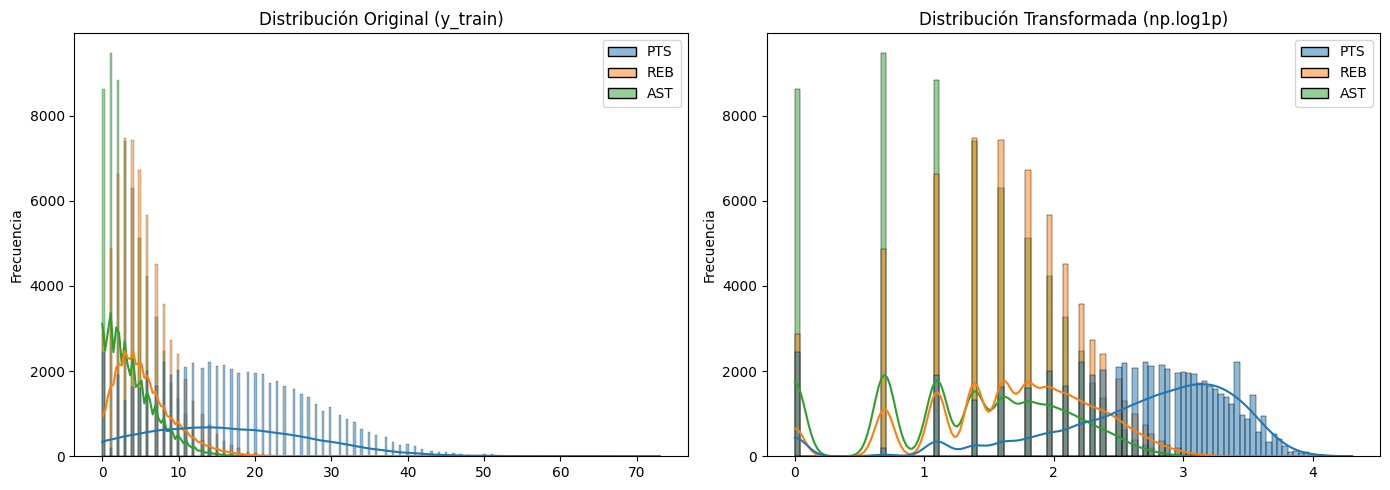

In [ ]:
y_train = df[['PTS', 'REB', 'AST']]


# Crear el lienzo con 1 fila y 2 columnas para comparar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfica de los datos originales
sns.histplot(y_train, kde=True, ax=axes[0], color='coral')
axes[0].set_title('Distribución Original (y_train)')
axes[0].set_ylabel('Frecuencia')

# 2. Gráfica aplicando np.log1p directamente en el gráfico
sns.histplot(np.log1p(y_train), kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribución Transformada (np.log1p)')
axes[1].set_ylabel('Frecuencia')

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

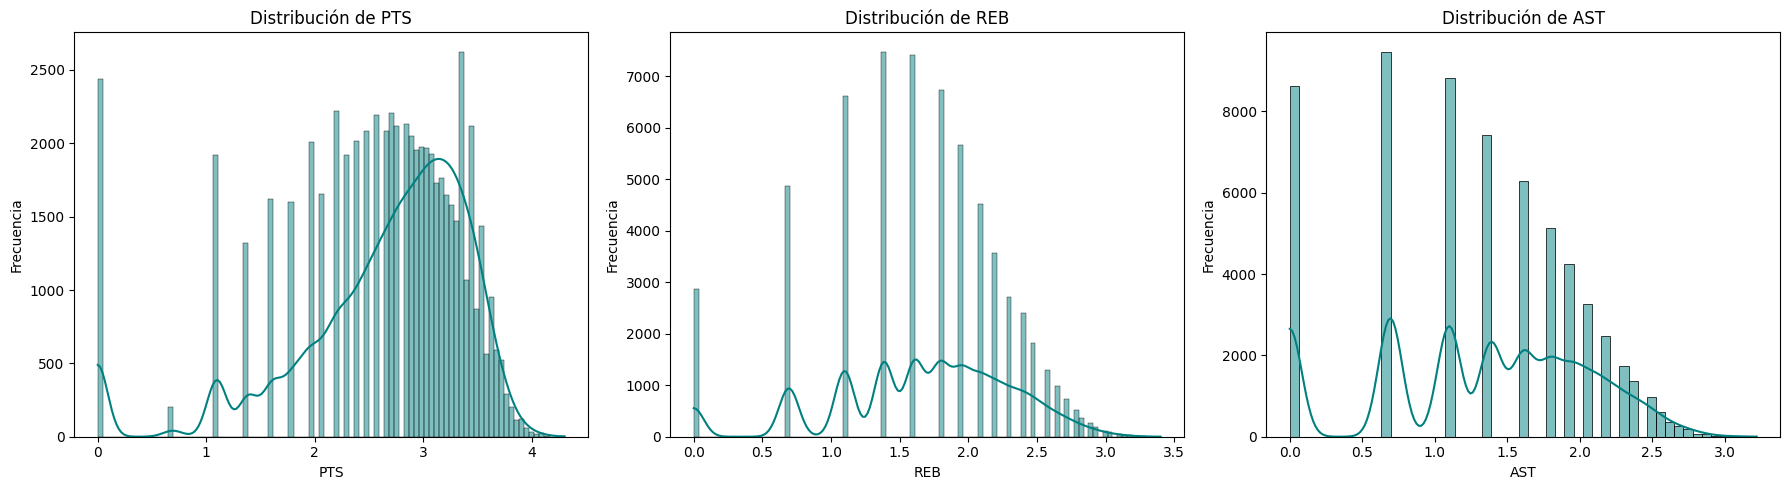

In [ ]:
columnas_objetivo = ['PTS', 'REB', 'AST']

# Crear un "lienzo" con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Iterar sobre las columnas para graficarlas una por una
for i, col in enumerate(columnas_objetivo):
    # histplot dibuja las barras, y kde=True dibuja la línea de la campana
    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[i], color='teal')

    # Personalizar un poco cada gráfica
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('Frecuencia')

# Ajustar los espacios y mostrar
plt.tight_layout()
plt.show()

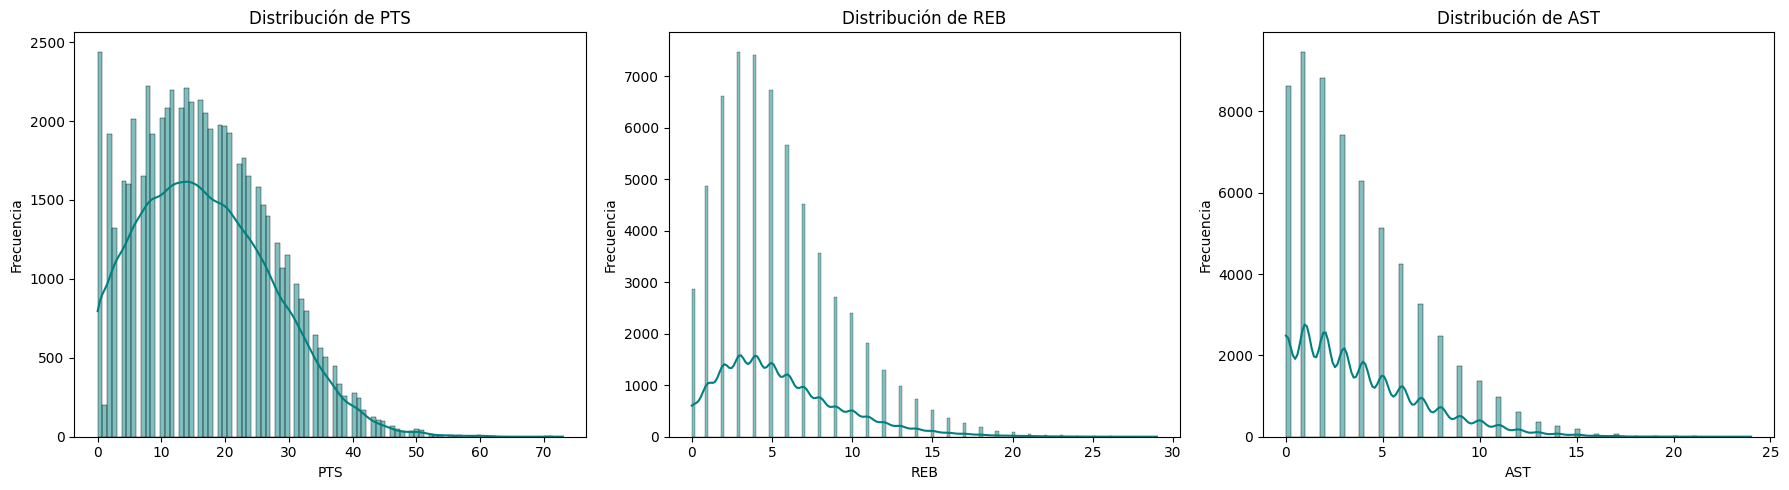

In [ ]:
columnas_objetivo = ['PTS', 'REB', 'AST']

# Crear un "lienzo" con 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Iterar sobre las columnas para graficarlas una por una
for i, col in enumerate(columnas_objetivo):
    # histplot dibuja las barras, y kde=True dibuja la línea de la campana
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal')

    # Personalizar un poco cada gráfica
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_ylabel('Frecuencia')

# Ajustar los espacios y mostrar
plt.tight_layout()
plt.show()

In [ ]:
lst_seasons = [
    '2003-04', '2004-05', '2005-06', '2006-07', '2007-08',
    '2008-09', '2009-10', '2010-11', '2011-12', '2012-13',
    '2013-14', '2014-15', '2015-16', '2016-17', '2017-18',
    '2018-19', '2019-20', '2020-21', '2021-22', '2022-23',# here
    '2023-24', '2024-25', '2025-26'
]

In [ ]:
len(lst_seasons)

23

In [ ]:
lst_seasons = [
    '2025-26'
]

for season in lst_seasons:
  print(f"--> season: {season}")
  adv_player_logs = playergamelogs.PlayerGameLogs(
      season_nullable=season,
      measure_type_player_game_logs_nullable='Advanced'
  ).get_data_frames()[0]

  df_usg = adv_player_logs[['GAME_ID', 'PLAYER_ID', 'USG_PCT']]

  lst_df_usg.append(df_usg)

  print(f"{season} was downloaded!")

  # Son milisegundos
  for i in tqdm(range(10), desc="Time out"):
    time.sleep(0.1)

display(f"Num of seassons saved: {len(lst_df_usg)}")

--> season: 2025-26
2025-26 was downloaded!


Time out:   0%|          | 0/10 [00:00<?, ?it/s]

'Num of seassons saved: 23'

In [ ]:
display(f"Num of seassons saved: {len(lst_df_usg)}")

'Num of seassons saved: 23'

In [ ]:
df_usg_final = pd.concat(lst_df_usg)
display(f"Num of matches: {len(df_usg_final)}")
df_usg_final.to_csv(f"df_usg_players_2003_04_to_2025_06.csv")

'Num of matches: 670289'

In [ ]:
for i in tqdm(range(2000), desc="Time out"):
  time.sleep(0.1)

In [ ]:
adv_team_logs = teamgamelogs.TeamGameLogs(
      season_nullable='2003-04',
      measure_type_player_game_logs_nullable='Advanced'
  ).get_data_frames()[0]

In [ ]:
display(adv_team_logs.columns)

display(adv_team_logs[['GAME_DATE', 'MATCHUP', 'PACE', 'E_PACE']])

Index(['SEASON_YEAR', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID',
       'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'E_OFF_RATING', 'OFF_RATING',
       'E_DEF_RATING', 'DEF_RATING', 'E_NET_RATING', 'NET_RATING', 'AST_PCT',
       'AST_TO', 'AST_RATIO', 'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT',
       'EFG_PCT', 'TS_PCT', 'E_PACE', 'PACE', 'PACE_PER40', 'POSS', 'PIE',
       'GP_RANK', 'W_RANK', 'L_RANK', 'W_PCT_RANK', 'MIN_RANK',
       'OFF_RATING_RANK', 'DEF_RATING_RANK', 'NET_RATING_RANK', 'AST_PCT_RANK',
       'AST_TO_RANK', 'AST_RATIO_RANK', 'OREB_PCT_RANK', 'DREB_PCT_RANK',
       'REB_PCT_RANK', 'TM_TOV_PCT_RANK', 'EFG_PCT_RANK', 'TS_PCT_RANK',
       'PACE_RANK', 'PIE_RANK', 'AVAILABLE_FLAG'],
      dtype='object')

,GAME_DATE,MATCHUP,PACE,E_PACE
0,2004-06-15T00:00:00,DET vs. LAL,88.0,86.8
1,2004-06-15T00:00:00,LAL @ DET,88.0,86.8
2,2004-06-13T00:00:00,DET vs. LAL,87.5,89.4
3,2004-06-13T00:00:00,LAL @ DET,87.5,89.4
4,2004-06-10T00:00:00,DET vs. LAL,88.0,87.5
...,...,...,...,...
2650,2003-10-07T00:00:00,HOU @ POR,94.0,93.8
2651,2003-10-06T00:00:00,MEM vs. MIL,107.5,106.3
2652,2003-10-06T00:00:00,MIL @ MEM,107.5,106.3
2653,2003-10-05T00:00:00,UTA vs. DAL,93.0,95.1


In [ ]:
lst_seasons = [
    '2003-04', '2004-05', '2005-06', '2006-07', '2007-08',
    '2008-09', '2009-10', '2010-11', '2011-12', '2012-13',
    '2013-14', '2014-15', '2015-16', '2016-17', '2017-18',
    '2018-19', '2019-20', '2020-21', '2021-22', '2022-23',
    '2023-24', '2024-25', '2025-26'
]

for season in lst_seasons:
  adv_team_logs = teamgamelogs.TeamGameLogs(
      season_nullable=season,
      measure_type_player_game_logs_nullable='Advanced'
  ).get_data_frames()[0]

  df_pace = adv_team_logs[['GAME_ID', 'TEAM_ID', 'PACE']]

  df_pace = df_pace.rename(columns={
    'TEAM_ID': 'OPPONENT_TEAM_ID',
    'PACE': 'OPP_PACE'
  })

  lst_df_pace.append(df_pace)

  # Son milisegundos
  for i in tqdm(range(1800), desc="Time out"):
    time.sleep(0.1)

display(f"Num of seassons saved: {len(lst_df_pace)}")


NameError: name 'lst_df_pace' is not defined

In [ ]:
display(f"Num of seassons saved: {len(lst_df_usg)}")

'Num of seassons saved: 23'

In [ ]:
df_pace_final = pd.concat(lst_df_pace)
display(f"Num of matches: {len(df_pace_final)}")
df_pace_final.to_csv(f"df_pace_teams_2003_04_to_2025_06.csv")

'Num of matches: 63377'

In [ ]:
display(df_usg_final.head(3))
display(df_pace_final.head(3))

,GAME_ID,PLAYER_ID,USG_PCT
0,0040300405,296.0,0.167
1,0040300405,2246.0,0.231
2,0040300405,922.0,0.083


,GAME_ID,OPPONENT_TEAM_ID,OPP_PACE
0,0040300405,1.610613e+09,88.0
1,0040300405,1.610613e+09,88.0
2,0040300404,1.610613e+09,87.5


In [ ]:
display(df_usg_final.isna().sum())
display(df_pace_final.isna().sum())

,0
GAME_ID,0
PLAYER_ID,98
USG_PCT,26


,0
GAME_ID,0
OPPONENT_TEAM_ID,81
OPP_PACE,0


In [ ]:
df_test = df_pace_final.copy()
df_test['OPPONENT_TEAM_ID'] = df_test['OPPONENT_TEAM_ID'].astype('Int64')

In [ ]:
df_test

,GAME_ID,OPPONENT_TEAM_ID,OPP_PACE
0,0040300405,1610612765,88.0
1,0040300405,1610612747,88.0
2,0040300404,1610612765,87.5
3,0040300404,1610612747,87.5
4,0040300403,1610612765,88.0
...,...,...,...
2783,0012500009,1610612740,102.0
2784,0012500009,15016,102.0
2785,0012500001,1610612747,102.0
2786,0012500008,1610612752,101.5


In [ ]:
df_test.to_csv(f"df_pace_teams_2003_04_to_2025_06_vol2.csv")

### Función para obtener el ID del jugador con su nombre

In [4]:
def get_player_id(_player_name):
  common_all_players = CommonAllPlayers(
    is_only_current_season = 1, # 1 active, 0 not active
    league_id = '00', # nba 00, g_league 20, wnba 10
    season = f'20{CURRENT_YEAR-1}-{CURRENT_YEAR}' # change year(s) if needed
  )

  df_common_players = common_all_players.get_data_frames()[0]
  df_common_players

  filtro = df_common_players["DISPLAY_FIRST_LAST"].str.lower() == _player_name.lower()
  player_id = df_common_players[filtro]["PERSON_ID"].values[0]

  return int(player_id)

## Obtener su última temporada **(TESTING)**

Nota: Aquí obtengo 6 partidos y quito el úlitmo para ver hacer un test con la predicción del modelo

In [6]:
CURRENT_YEAR = 26
SEASON = '2025-26'
PLAYER_NAME = "MIKAL BRIDGES"
PLAYER_ID = get_player_id(PLAYER_NAME)

print(f"ID: {PLAYER_ID}")

ID: 1628969


In [7]:
player_game_logs = PlayerGameLogs(player_id_nullable=PLAYER_ID,
                                  season_nullable=SEASON)

name = player_game_logs.get_data_frames()[0]

df = name.copy()
df.head(2)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05T00:00:00,NYK @ SAS,...,10,19,44,20,2,1,13,1,40:53,1
1,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03T00:00:00,NYK @ SAS,...,10,86,33,75,2,1,80,1,28:12,1


In [8]:
df.sort_values('GAME_DATE').reset_index(drop=True)
df

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05T00:00:00,NYK @ SAS,...,10,19,44,20,2,1,13,1,40:53,1
1,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03T00:00:00,NYK @ SAS,...,10,86,33,75,2,1,80,1,28:12,1
2,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25T00:00:00,NYK @ CLE,...,1,40,38,69,2,1,64,1,30:07,1
3,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23T00:00:00,NYK @ CLE,...,23,12,13,8,2,1,9,1,39:17,1
4,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21T00:00:00,NYK vs. CLE,...,48,21,11,44,2,1,44,1,39:45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500003,2025-10-22T00:00:00,NYK vs. CLE,...,23,33,60,7,2,1,13,1,33:12,1
99,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500066,2025-10-17T00:00:00,NYK vs. CHA,...,79,33,75,16,2,1,17,1,33:27,1
100,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500039,2025-10-09T00:00:00,NYK vs. MIN,...,48,40,75,47,2,1,38,1,25:23,1
101,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500010,2025-10-04T00:00:00,NYK @ PHI,...,48,74,47,87,2,1,86,1,16:34,1


In [9]:
df_6_games = df.head(6)
df_6_games

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05T00:00:00,NYK @ SAS,...,10,19,44,20,2,1,13,1,40:53,1
1,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03T00:00:00,NYK @ SAS,...,10,86,33,75,2,1,80,1,28:12,1
2,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25T00:00:00,NYK @ CLE,...,1,40,38,69,2,1,64,1,30:07,1
3,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23T00:00:00,NYK @ CLE,...,23,12,13,8,2,1,9,1,39:17,1
4,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21T00:00:00,NYK vs. CLE,...,48,21,11,44,2,1,44,1,39:45,1
5,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500301,2026-05-19T00:00:00,NYK vs. CLE,...,1,24,31,52,2,1,34,1,42:18,1


In [ ]:
df_last_5_games = df_6_games.tail(5).copy()
df_last_5_games

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
1,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23T00:00:00,NYK @ CLE,...,21,12,13,8,2,1,9,1,39:17,1
2,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21T00:00:00,NYK vs. CLE,...,46,20,11,43,2,1,43,1,39:45,1
3,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500301,2026-05-19T00:00:00,NYK vs. CLE,...,1,23,31,51,2,1,33,1,42:18,1
4,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500214,2026-05-10T00:00:00,NYK @ PHI,...,21,59,2,31,2,1,43,1,28:18,1
5,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500213,2026-05-08T00:00:00,NYK @ PHI,...,10,8,23,30,2,1,25,1,36:54,1


In [ ]:
df_last_5_games = df_6_games.head(5).copy()
df_last_5_games

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25T00:00:00,NYK @ CLE,...,1,39,37,68,2,1,63,1,30:07,1
1,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23T00:00:00,NYK @ CLE,...,21,12,13,8,2,1,9,1,39:17,1
2,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21T00:00:00,NYK vs. CLE,...,46,20,11,43,2,1,43,1,39:45,1
3,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500301,2026-05-19T00:00:00,NYK vs. CLE,...,1,23,31,51,2,1,33,1,42:18,1
4,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500214,2026-05-10T00:00:00,NYK @ PHI,...,21,59,2,31,2,1,43,1,28:18,1


In [ ]:
display(df_6_games.head(1))
display(df_6_games.head(1)[['PTS', 'REB', 'AST']])

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25T00:00:00,NYK @ CLE,...,1,39,37,68,2,1,63,1,30:07,1


,PTS,REB,AST
0,15,3,5


## <font color=#93EB21>Obtener los primeros 5 juegos

In [73]:
CURRENT_YEAR = 26
SEASON = '2025-26'
PLAYER_NAME = "MIKAL BRIDGES"
PLAYER_ID = get_player_id(PLAYER_NAME)

print(f"ID: {PLAYER_ID}")

player_game_logs = PlayerGameLogs(player_id_nullable=PLAYER_ID,
                                  season_nullable=SEASON)

name = player_game_logs.get_data_frames()[0]

df = name.copy()
df.sort_values('GAME_DATE').reset_index(drop=True)

df_all_sesson = df.copy()

df_5_games_current = df.head(5)
display(df_5_games_current)
display(df_5_games_current.head(1)[['PTS', 'REB', 'AST']])

ID: 1628969


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05T00:00:00,NYK @ SAS,...,10,19,44,20,2,1,13,1,40:53,1
1,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03T00:00:00,NYK @ SAS,...,10,86,33,75,2,1,80,1,28:12,1
2,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25T00:00:00,NYK @ CLE,...,1,40,38,69,2,1,64,1,30:07,1
3,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23T00:00:00,NYK @ CLE,...,23,12,13,8,2,1,9,1,39:17,1
4,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21T00:00:00,NYK vs. CLE,...,48,21,11,44,2,1,44,1,39:45,1


,PTS,REB,AST
0,20,6,6


In [16]:
adv_player_logs = playergamelogs.PlayerGameLogs(
      season_nullable=SEASON,
      measure_type_player_game_logs_nullable='Advanced'
  ).get_data_frames()[0]

df_usg = adv_player_logs[['GAME_ID', 'PLAYER_ID', 'USG_PCT']]

display(df_usg)

,GAME_ID,PLAYER_ID,USG_PCT
0,0042500402,1629011,0.171
1,0042500402,1626157,0.188
2,0042500402,1628368,0.219
3,0042500402,1628969,0.144
4,0042500402,1641705,0.308
...,...,...,...
30733,0012500008,201569,0.156
30734,0012500008,1627824,0.125
30735,0012500008,1642885,0.138
30736,0012500008,1628404,0.100


In [13]:
adv_team_logs = teamgamelogs.TeamGameLogs(
      season_nullable=SEASON,
      measure_type_player_game_logs_nullable='Advanced'
  ).get_data_frames()[0]

df_pace = adv_team_logs[['GAME_ID', 'TEAM_ID', 'PACE']]

df_pace = df_pace.rename(columns={
    'TEAM_ID': 'OPPONENT_TEAM_ID',
    'PACE': 'OPP_PACE'
  })

display(df_pace)

,GAME_ID,OPPONENT_TEAM_ID,OPP_PACE
0,0042500402,1610612752,98.0
1,0042500402,1610612759,98.0
2,0042500401,1610612752,99.5
3,0042500401,1610612759,99.5
4,0042500317,1610612759,93.0
...,...,...,...
2783,0012500009,1610612740,102.0
2784,0012500009,15016,102.0
2785,0012500001,1610612747,102.0
2786,0012500008,1610612752,101.5


## Ingenería de características 1

In [74]:
#df_train = df_5_games_current.copy()
df_train = df_all_sesson.copy()

In [75]:
# Nos aseguramos que el tipo de dato sea str
df_train['MATCHUP'] = df_train['MATCHUP'].astype(str)

# ¿Juegan de local o de visitante?
df_train["IS_HOME"] = df_train["MATCHUP"].apply(lambda x: 1 if "@" not in str(x) else 0)

# Establecer como tipo fecha
df_train["GAME_DATE"] = pd.to_datetime(df_train["GAME_DATE"])

# --> (DF DE JUGADORES): Ordenar por jugador y por fecha
df_train = df_train.sort_values(by=["PLAYER_ID", "GAME_DATE"])

# --> (DF DE JUGADORES): Obtenemos los días de descanso entre juegos
  # Agrupamos por jugador antes de calcular la diferencia
df_train["DAYS_REST"] = df_train.groupby("PLAYER_ID")["GAME_DATE"].diff().dt.days

# Llenamos los días faltantes con 0 días de descanso
df_train["DAYS_REST"] = df_train["DAYS_REST"].fillna(0)

# Obtenemos el nombre del oponente
df_train['OPPONENT'] = df_train['MATCHUP'].apply(lambda x: x.split(' ')[-1])

display(df_train.head(5))
display(df_train.shape)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,IS_HOME,DAYS_REST,OPPONENT
102,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500008,2025-10-02,NYK @ PHI,...,94,2,1,86,1,17:10,1,0,0.0,PHI
101,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500010,2025-10-04,NYK @ PHI,...,87,2,1,86,1,16:34,1,0,2.0,PHI
100,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500039,2025-10-09,NYK vs. MIN,...,47,2,1,38,1,25:23,1,1,5.0,MIN
99,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500066,2025-10-17,NYK vs. CHA,...,16,2,1,17,1,33:27,1,1,8.0,CHA
98,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500003,2025-10-22,NYK vs. CLE,...,7,2,1,13,1,33:12,1,1,5.0,CLE


(103, 73)

In [76]:
df_teams_abrev_list = pd.read_csv((f'abbreviation_team_list.csv'))

def get_team_id(abrev_team_name):
  df_teams_abrev_list = pd.read_csv((f'abbreviation_team_list.csv'))
  return int(df_teams_abrev_list[df_teams_abrev_list['ABBREVIATION'] == abrev_team_name]['TEAM_ID'].values[0])

In [77]:
team_map = df_teams_abrev_list.set_index('ABBREVIATION')['TEAM_ID'].to_dict()
df_train['OPPONENT_TEAM_ID'] = df_train['OPPONENT'].map(team_map)
df_train = df_train.dropna(subset=['OPPONENT_TEAM_ID'])
df_train['OPPONENT_TEAM_ID'] = df_train['OPPONENT_TEAM_ID'].astype(int)

display(df_train.head(3))
display(df_train.shape)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,IS_HOME,DAYS_REST,OPPONENT,OPPONENT_TEAM_ID
102,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500008,2025-10-02,NYK @ PHI,...,2,1,86,1,17:10,1,0,0.0,PHI,1610612755
101,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500010,2025-10-04,NYK @ PHI,...,2,1,86,1,16:34,1,0,2.0,PHI,1610612755
100,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500039,2025-10-09,NYK vs. MIN,...,2,1,38,1,25:23,1,1,5.0,MIN,1610612750


(103, 74)

In [78]:
# Historial H2H del jugador contra cada rival
df_player = df_train.sort_values(['PLAYER_ID', 'OPPONENT_TEAM_ID','GAME_DATE'])

for stat in ['PTS','AST','REB']:
    df_player[f'H2H_{stat}_AVG'] = (
        df_player
        .groupby(['PLAYER_ID','OPPONENT_TEAM_ID'])[stat]
        .transform(lambda x: x.shift(1)                 # excluye el mismo partido
                             .expanding(min_periods=1)  # todos los previos
                             .mean()
        )
    )

display(len(df_player))
display(df_player.head())

103

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,IS_HOME,DAYS_REST,OPPONENT,OPPONENT_TEAM_ID,H2H_PTS_AVG,H2H_AST_AVG,H2H_REB_AVG
67,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500435,2025-12-27,NYK @ ATL,...,1,36:38,1,0,2.0,ATL,1610612737,NaN,NaN,NaN
64,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500479,2026-01-02,NYK vs. ATL,...,1,35:09,1,1,2.0,ATL,1610612737,14.000000,8.0,3.000000
19,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022501143,2026-04-06,NYK @ ATL,...,1,31:57,1,0,3.0,ATL,1610612737,16.000000,6.5,4.000000
15,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500121,2026-04-18,NYK vs. ATL,...,1,31:36,1,1,6.0,ATL,1610612737,15.666667,5.0,4.333333
14,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500122,2026-04-20,NYK vs. ATL,...,1,37:02,1,1,2.0,ATL,1610612737,14.500000,4.0,3.750000


In [79]:
display(df_player.head())

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,IS_HOME,DAYS_REST,OPPONENT,OPPONENT_TEAM_ID,H2H_PTS_AVG,H2H_AST_AVG,H2H_REB_AVG
67,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500435,2025-12-27,NYK @ ATL,...,1,36:38,1,0,2.0,ATL,1610612737,NaN,NaN,NaN
64,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500479,2026-01-02,NYK vs. ATL,...,1,35:09,1,1,2.0,ATL,1610612737,14.000000,8.0,3.000000
19,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022501143,2026-04-06,NYK @ ATL,...,1,31:57,1,0,3.0,ATL,1610612737,16.000000,6.5,4.000000
15,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500121,2026-04-18,NYK vs. ATL,...,1,31:36,1,1,6.0,ATL,1610612737,15.666667,5.0,4.333333
14,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500122,2026-04-20,NYK vs. ATL,...,1,37:02,1,1,2.0,ATL,1610612737,14.500000,4.0,3.750000


In [80]:
df_matches_record_1 = pd.read_csv((f'teams_matches_nba_2015.csv'))
df_matches_record_2 = pd.read_csv((f'teams_matches_nba_from_05-12-2026_to_05-27-2026.csv'))
df_matches_record_3 = pd.read_csv((f'teams_matches_nba_from_05-27-2026_to_06-07-2026.csv'))

display(f"Matches record 1: {df_matches_record_1.shape}")
display(f"Matches record 2: {df_matches_record_2.shape}")
display(f"Matches record 3: {df_matches_record_3.shape}")

teams_df = pd.concat([df_matches_record_1,
                      df_matches_record_2,
                      df_matches_record_3],
                     ignore_index=True)

teams_df = teams_df.drop(columns=['Unnamed: 0'])
display(teams_df.shape)
display(teams_df.head(5))

'Matches record 1: (30512, 58)'

'Matches record 2: (28, 58)'

'Matches record 3: (8, 58)'

(30548, 57)

,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG
0,2025-26,1610612746,LAC,LA Clippers,52500131,2026-04-15,LAC vs. GSW,L,48.0,45,...,5,69,4,59,21,72,50,20,57,1.0
1,2025-26,1610612746,LAC,LA Clippers,22501199,2026-04-12,LAC vs. GSW,W,48.0,42,...,20,7,86,46,21,77,29,35,35,1.0
2,2025-26,1610612746,LAC,LA Clippers,22501183,2026-04-10,LAC @ POR,L,48.0,36,...,83,67,69,59,72,82,80,82,78,1.0
3,2025-26,1610612746,LAC,LA Clippers,22501163,2026-04-08,LAC vs. OKC,L,48.0,40,...,20,33,36,59,72,32,14,52,76,1.0
4,2025-26,1610612746,LAC,LA Clippers,22501156,2026-04-07,LAC vs. DAL,W,48.0,41,...,52,45,69,5,72,32,40,33,23,1.0


In [81]:
df_play_teams = teams_df.copy()

df_play_teams = df_play_teams.sort_values('GAME_DATE').reset_index(drop=True)
df_play_teams = df_play_teams.tail(10)
display(df_play_teams)

,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG
30538,2025-26,1610612760,OKC,Oklahoma City Thunder,42500315,2026-05-26,OKC vs. SAS,W,48.0,40,...,3,4,3,2,1,2,1,1,2,1.0
30539,2025-26,1610612759,SAS,San Antonio Spurs,42500315,2026-05-26,SAS @ OKC,L,48.0,37,...,3,2,1,7,5,7,5,4,6,1.0
30540,2025-26,1610612759,SAS,San Antonio Spurs,42500316,2026-05-28,SAS vs. OKC,W,48.0,41,...,1,2,2,1,1,1,3,1,1,1.0
30541,2025-26,1610612760,OKC,Oklahoma City Thunder,42500316,2026-05-28,OKC @ SAS,L,48.0,35,...,2,1,1,2,2,2,2,2,2,1.0
30542,2025-26,1610612760,OKC,Oklahoma City Thunder,42500317,2026-05-30,OKC vs. SAS,L,48.0,37,...,1,2,1,1,1,1,1,1,1,1.0
30543,2025-26,1610612759,SAS,San Antonio Spurs,42500317,2026-05-30,SAS @ OKC,W,48.0,40,...,3,1,1,4,3,2,4,2,2,1.0
30544,2025-26,1610612752,NYK,New York Knicks,42500401,2026-06-03,NYK @ SAS,W,48.0,39,...,2,1,2,2,1,1,1,1,1,1.0
30545,2025-26,1610612759,SAS,San Antonio Spurs,42500401,2026-06-03,SAS vs. NYK,L,48.0,32,...,4,2,4,3,2,4,1,4,4,1.0
30546,2025-26,1610612752,NYK,New York Knicks,42500402,2026-06-05,NYK @ SAS,W,48.0,37,...,1,2,1,1,2,1,2,1,2,1.0
30547,2025-26,1610612759,SAS,San Antonio Spurs,42500402,2026-06-05,SAS vs. NYK,L,48.0,37,...,2,4,2,1,4,3,1,3,3,1.0


In [82]:
display(teams_df.shape)
display(teams_df.head(3))

(30548, 57)

,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG
0,2025-26,1610612746,LAC,LA Clippers,52500131,2026-04-15,LAC vs. GSW,L,48.0,45,...,5,69,4,59,21,72,50,20,57,1.0
1,2025-26,1610612746,LAC,LA Clippers,22501199,2026-04-12,LAC vs. GSW,W,48.0,42,...,20,7,86,46,21,77,29,35,35,1.0
2,2025-26,1610612746,LAC,LA Clippers,22501183,2026-04-10,LAC @ POR,L,48.0,36,...,83,67,69,59,72,82,80,82,78,1.0


In [83]:
# Nos aseguramos que el tipo de dato sea str
teams_df['MATCHUP'] = teams_df['MATCHUP'].astype(str)

# Obtener el oponente
teams_df['OPPONENT'] = teams_df['MATCHUP'].apply(lambda x: x.split(' ')[-1])

team_map = teams_df.set_index('TEAM_ABBREVIATION')['TEAM_ID'].to_dict()
teams_df['OPPONENT_TEAM_ID'] = teams_df['OPPONENT'].map(team_map)
teams_df = teams_df.dropna(subset=['OPPONENT_TEAM_ID'])
teams_df['OPPONENT_TEAM_ID'] = teams_df['OPPONENT_TEAM_ID'].astype(int)

display(teams_df.head(3))
display(teams_df.shape)

,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG,OPPONENT,OPPONENT_TEAM_ID
0,2025-26,1610612746,LAC,LA Clippers,52500131,2026-04-15,LAC vs. GSW,L,48.0,45,...,4,59,21,72,50,20,57,1.0,GSW,1610612744
1,2025-26,1610612746,LAC,LA Clippers,22501199,2026-04-12,LAC vs. GSW,W,48.0,42,...,86,46,21,77,29,35,35,1.0,GSW,1610612744
2,2025-26,1610612746,LAC,LA Clippers,22501183,2026-04-10,LAC @ POR,L,48.0,36,...,69,59,72,82,80,82,78,1.0,POR,1610612757


(30473, 59)

In [84]:
# Extraer los stats del Oponente en cada juego (GAME ID)
# Creamos un dataframe con los valores ofensivos de cada equipo
#   - Renombrando ciertas vairables por ejemplo: TEAM_ID → OPPONENT_ID

opp = (
    teams_df[
        ['GAME_ID','TEAM_ID','PTS','REB','AST','FG_PCT']
    ]
    .rename(columns={
        'TEAM_ID':'OPPONENT_ID',
        'PTS':'OPP_PTS',
        'REB':'OPP_REB',
        'AST':'OPP_AST',
        'FG_PCT':'OPP_FG_PCT'
    })
)

opp.head()

,GAME_ID,OPPONENT_ID,OPP_PTS,OPP_REB,OPP_AST,OPP_FG_PCT
0,52500131,1610612746,121,36,30,0.523
1,22501199,1610612746,115,44,27,0.472
2,22501183,1610612746,97,35,17,0.434
3,22501163,1610612746,110,36,27,0.465
4,22501156,1610612746,116,56,23,0.446


In [85]:
# Hacemos merge sobre teams_df
# El merge se toma en cuenta el GAME_ID
# y filtramos para quedarnos sólo con el rival

teams_df = (
    teams_df
    .merge(opp, on='GAME_ID')
    .query('TEAM_ID != OPPONENT_ID')  # ahora, cada fila tiene los stats del rival
)

teams_df.head()

,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG,OPPONENT,OPPONENT_TEAM_ID,OPPONENT_ID,OPP_PTS,OPP_REB,OPP_AST,OPP_FG_PCT
1,2025-26,1610612746,LAC,LA Clippers,52500131,2026-04-15,LAC vs. GSW,L,48.0,45,...,20,57,1.0,GSW,1610612744,1610612744,126,36,29,0.566
3,2025-26,1610612746,LAC,LA Clippers,22501199,2026-04-12,LAC vs. GSW,W,48.0,42,...,35,35,1.0,GSW,1610612744,1610612744,110,47,24,0.419
5,2025-26,1610612746,LAC,LA Clippers,22501183,2026-04-10,LAC @ POR,L,48.0,36,...,82,78,1.0,POR,1610612757,1610612757,116,46,23,0.446
7,2025-26,1610612746,LAC,LA Clippers,22501163,2026-04-08,LAC vs. OKC,L,48.0,40,...,52,76,1.0,OKC,1610612760,1610612760,128,44,30,0.578
9,2025-26,1610612746,LAC,LA Clippers,22501156,2026-04-07,LAC vs. DAL,W,48.0,41,...,33,23,1.0,DAL,1610612742,1610612742,103,54,18,0.350


In [86]:
teams_df = teams_df.sort_values(['TEAM_ID','GAME_DATE'])

In [87]:
# shift(1): Ignora el partido de hoy.
# rolling(5): Agarra los 5 anteriores.
# min_periods=1: Si solo hay 1, 2, 3 o 4 partidos previos, promedia esos (evita que se borren filas).
def last_5_mean_match_stats(serie):
  return serie.shift(1).rolling(window=5, min_periods=1).mean()

In [88]:
# Calcular medias móviles de últimos 5 partidos del rival
for stat in ['OPP_PTS','OPP_REB','OPP_AST','OPP_FG_PCT']:
    teams_df[f'{stat}_ALLOWED_AVG'] = (
        teams_df
        .groupby('TEAM_ID')[stat]
        .transform(lambda x: x.shift(1)                     # excluye el mismo partido
                              .rolling(5, min_periods=1)    # ventana de 5 previos
                              .mean()
        )
    )

In [89]:
# Calcular media “a nivel liga” de lo que permite cada rival
opp_allowed = (
    teams_df
    .groupby('TEAM_ID')[['OPP_PTS','OPP_REB','OPP_AST', 'OPP_FG_PCT']]
    .mean()
    .rename(columns={
        'OPP_PTS':'OPP_PTS_AVG_LEAGUE',
        'OPP_REB':'OPP_REB_AVG_LEAGUE',
        'OPP_AST':'OPP_AST_AVG_LEAGUE',
        'OPP_FG_PCT':'OPP_FG_PCT_AVG_LEAGUE',
    })
    .reset_index()
)

opp_allowed.head()

,TEAM_ID,OPP_PTS_AVG_LEAGUE,OPP_REB_AVG_LEAGUE,OPP_AST_AVG_LEAGUE,OPP_FG_PCT_AVG_LEAGUE
0,1610612737,112.906000,44.799000,25.529000,0.467976
1,1610612738,106.204360,43.858311,22.802906,0.447530
2,1610612739,109.049856,42.938639,24.708533,0.466989
3,1610612740,113.042989,44.474923,25.504606,0.467208
4,1610612741,111.547347,44.695109,25.765869,0.467482


In [90]:
df_player_train = df_player.copy()
df_all_games_train = teams_df.copy()

In [91]:
df_player_train['GAME_DATE'] = pd.to_datetime(df_player_train['GAME_DATE'])
df_all_games_train['GAME_DATE'] = pd.to_datetime(df_all_games_train['GAME_DATE'])

In [92]:
display(df_player_train.shape)
display(df_player_train.head(2))
display(df_all_games_train.shape)
display(df_all_games_train.head(2))

(103, 77)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,IS_HOME,DAYS_REST,OPPONENT,OPPONENT_TEAM_ID,H2H_PTS_AVG,H2H_AST_AVG,H2H_REB_AVG
67,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500435,2025-12-27,NYK @ ATL,...,1,36:38,1,0,2.0,ATL,1610612737,NaN,NaN,NaN
64,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500479,2026-01-02,NYK vs. ATL,...,1,35:09,1,1,2.0,ATL,1610612737,14.0,8.0,3.0


(31000, 68)

,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,OPPONENT_TEAM_ID,OPPONENT_ID,OPP_PTS,OPP_REB,OPP_AST,OPP_FG_PCT,OPP_PTS_ALLOWED_AVG,OPP_REB_ALLOWED_AVG,OPP_AST_ALLOWED_AVG,OPP_FG_PCT_ALLOWED_AVG
48352,2015-16,1610612737,ATL,Atlanta Hawks,11500017,2015-10-07,ATL @ CLE,W,48.0,33,...,1610612739,1610612739,96,39,28,0.422,NaN,NaN,NaN,NaN
48350,2015-16,1610612737,ATL,Atlanta Hawks,11500032,2015-10-09,ATL @ NOP,W,48.0,33,...,1610612740,1610612740,93,44,15,0.381,96.0,39.0,28.0,0.422


In [93]:
df_merged = df_player_train.merge(
    df_all_games_train[[
        'TEAM_ID','GAME_DATE',
        'OPP_PTS_ALLOWED_AVG','OPP_REB_ALLOWED_AVG',
        'OPP_AST_ALLOWED_AVG','OPP_FG_PCT_ALLOWED_AVG'
    ]],
    left_on = ['OPPONENT_TEAM_ID','GAME_DATE'],
    right_on= ['TEAM_ID','GAME_DATE'],
    how='left'
)

display(df_merged.shape)
display(df_merged.head())

(105, 82)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID_x,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,OPPONENT,OPPONENT_TEAM_ID,H2H_PTS_AVG,H2H_AST_AVG,H2H_REB_AVG,TEAM_ID_y,OPP_PTS_ALLOWED_AVG,OPP_REB_ALLOWED_AVG,OPP_AST_ALLOWED_AVG,OPP_FG_PCT_ALLOWED_AVG
0,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500435,2025-12-27,NYK @ ATL,...,ATL,1610612737,NaN,NaN,NaN,1610612737,132.6,46.6,35.0,0.5266
1,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500479,2026-01-02,NYK vs. ATL,...,ATL,1610612737,14.000000,8.0,3.000000,1610612737,124.4,50.0,28.0,0.4790
2,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022501143,2026-04-06,NYK @ ATL,...,ATL,1610612737,16.000000,6.5,4.000000,1610612737,106.4,42.4,24.8,0.4514
3,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500121,2026-04-18,NYK vs. ATL,...,ATL,1610612737,15.666667,5.0,4.333333,1610612737,116.4,42.4,26.8,0.4952
4,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500122,2026-04-20,NYK vs. ATL,...,ATL,1610612737,14.500000,4.0,3.750000,1610612737,117.6,44.8,26.4,0.4914


In [94]:
# shift(1): Ignora el partido de hoy.
# rolling(5): Agarra los 5 anteriores.
# min_periods=1: Si solo hay 1, 2, 3 o 4 partidos previos, promedia esos (evita que se borren filas).

def last_5_mean_match_stats(serie):
  return serie.shift(1).rolling(window=5, min_periods=1).mean()

In [95]:
df_train = df_merged.sort_values(by=['GAME_DATE'])
cols_perfomance = [
    'MIN', 'FGA', 'FGM', 'FG3A', 'FG3M', 'FTA', 'FTM',
    'TOV', 'STL', 'BLK', 'PF', 'PLUS_MINUS'
]

for col in cols_perfomance:
  new_name_col = f'{col}_L5_AVG'

  df_train[new_name_col] = df_train.groupby('PLAYER_ID')[col].transform(last_5_mean_match_stats)

display(df_train.head())

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID_x,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,FGM_L5_AVG,FG3A_L5_AVG,FG3M_L5_AVG,FTA_L5_AVG,FTM_L5_AVG,TOV_L5_AVG,STL_L5_AVG,BLK_L5_AVG,PF_L5_AVG,PLUS_MINUS_L5_AVG
60,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500008,2025-10-02,NYK @ PHI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500010,2025-10-04,NYK @ PHI,...,4.000000,5.0,2.000000,2.000000,0.000000,1.000000,2.000000,0.000000,2.000000,11.000000
45,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500039,2025-10-09,NYK vs. MIN,...,4.000000,2.5,1.000000,2.000000,1.000000,1.500000,1.000000,1.000000,2.000000,8.500000
100,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500066,2025-10-17,NYK vs. CHA,...,4.666667,4.0,1.666667,1.333333,0.666667,1.333333,1.666667,0.666667,2.333333,4.333333
13,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500003,2025-10-22,NYK vs. CLE,...,5.250000,5.0,1.750000,1.000000,0.500000,1.750000,1.750000,1.000000,2.750000,2.250000


## Ingenería de características 2

* True shooting
* USG
* Pace del juego

In [104]:
df = df_train.copy()
df.sort_values('GAME_DATE').reset_index(drop=True)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID_x,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,FGM_L5_AVG,FG3A_L5_AVG,FG3M_L5_AVG,FTA_L5_AVG,FTM_L5_AVG,TOV_L5_AVG,STL_L5_AVG,BLK_L5_AVG,PF_L5_AVG,PLUS_MINUS_L5_AVG
0,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500008,2025-10-02,NYK @ PHI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500010,2025-10-04,NYK @ PHI,...,4.000000,5.0,2.000000,2.000000,0.000000,1.000000,2.000000,0.000000,2.000000,11.000000
2,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500039,2025-10-09,NYK vs. MIN,...,4.000000,2.5,1.000000,2.000000,1.000000,1.500000,1.000000,1.000000,2.000000,8.500000
3,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0012500066,2025-10-17,NYK vs. CHA,...,4.666667,4.0,1.666667,1.333333,0.666667,1.333333,1.666667,0.666667,2.333333,4.333333
4,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0022500003,2025-10-22,NYK vs. CLE,...,5.250000,5.0,1.750000,1.000000,0.500000,1.750000,1.750000,1.000000,2.750000,2.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21,NYK vs. CLE,...,7.400000,3.4,1.400000,1.400000,1.400000,0.800000,1.800000,0.200000,2.000000,16.800000
101,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23,NYK @ CLE,...,7.800000,2.6,1.000000,1.400000,1.400000,0.800000,1.800000,0.200000,1.800000,17.000000
102,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25,NYK @ CLE,...,8.200000,2.4,1.000000,1.400000,1.400000,1.200000,2.200000,0.400000,1.600000,19.400000
103,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03,NYK @ SAS,...,7.400000,3.2,0.800000,1.600000,1.600000,1.600000,1.800000,0.400000,1.400000,18.400000


In [106]:
df.tail(5)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID_x,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,FGM_L5_AVG,FG3A_L5_AVG,FG3M_L5_AVG,FTA_L5_AVG,FTM_L5_AVG,TOV_L5_AVG,STL_L5_AVG,BLK_L5_AVG,PF_L5_AVG,PLUS_MINUS_L5_AVG
17,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21,NYK vs. CLE,...,7.4,3.4,1.4,1.4,1.4,0.8,1.8,0.2,2.0,16.8
18,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23,NYK @ CLE,...,7.8,2.6,1.0,1.4,1.4,0.8,1.8,0.2,1.8,17.0
19,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25,NYK @ CLE,...,8.2,2.4,1.0,1.4,1.4,1.2,2.2,0.4,1.6,19.4
79,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03,NYK @ SAS,...,7.4,3.2,0.8,1.6,1.6,1.6,1.8,0.4,1.4,18.4
80,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05,NYK @ SAS,...,6.8,2.8,0.8,2.4,2.2,1.6,1.6,0.4,1.8,14.4


### Pace del juego

In [107]:
df = df.merge(df_pace[['GAME_ID', 'OPPONENT_TEAM_ID', 'OPP_PACE']],
              left_on=['GAME_ID', 'OPPONENT_TEAM_ID'],
              right_on=['GAME_ID', 'OPPONENT_TEAM_ID'],
              how='left').drop(columns=['OPPONENT_TEAM_ID'])

display(df['OPP_PACE'].isna().sum())
display(df.tail(5))

np.int64(0)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID_x,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,FG3A_L5_AVG,FG3M_L5_AVG,FTA_L5_AVG,FTM_L5_AVG,TOV_L5_AVG,STL_L5_AVG,BLK_L5_AVG,PF_L5_AVG,PLUS_MINUS_L5_AVG,OPP_PACE
100,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21,NYK vs. CLE,...,3.4,1.4,1.4,1.4,0.8,1.8,0.2,2.0,16.8,89.0
101,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23,NYK @ CLE,...,2.6,1.0,1.4,1.4,0.8,1.8,0.2,1.8,17.0,97.5
102,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25,NYK @ CLE,...,2.4,1.0,1.4,1.4,1.2,2.2,0.4,1.6,19.4,102.0
103,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03,NYK @ SAS,...,3.2,0.8,1.6,1.6,1.6,1.8,0.4,1.4,18.4,99.5
104,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05,NYK @ SAS,...,2.8,0.8,2.4,2.2,1.6,1.6,0.4,1.8,14.4,98.0


In [108]:
df = df.sort_values(by=['PLAYER_ID', 'GAME_DATE'])

df['OPP_PACE_AVG'] = df.groupby('PLAYER_ID')['OPP_PACE'].transform(
    lambda x: x.rolling(window=5, min_periods=1).mean().shift(1)
)

display(df.shape)
display(df['OPP_PACE_AVG'].isna().sum())
display(df.tail(5))

(105, 95)

np.int64(1)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID_x,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,FG3M_L5_AVG,FTA_L5_AVG,FTM_L5_AVG,TOV_L5_AVG,STL_L5_AVG,BLK_L5_AVG,PF_L5_AVG,PLUS_MINUS_L5_AVG,OPP_PACE,OPP_PACE_AVG
100,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21,NYK vs. CLE,...,1.4,1.4,1.4,0.8,1.8,0.2,2.0,16.8,89.0,96.552
101,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23,NYK @ CLE,...,1.0,1.4,1.4,0.8,1.8,0.2,1.8,17.0,97.5,94.652
102,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25,NYK @ CLE,...,1.0,1.4,1.4,1.2,2.2,0.4,1.6,19.4,102.0,95.252
103,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03,NYK @ SAS,...,0.8,1.6,1.6,1.6,1.8,0.4,1.4,18.4,99.5,96.952
104,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05,NYK @ SAS,...,0.8,2.4,2.2,1.6,1.6,0.4,1.8,14.4,98.0,97.252


### USG del jugador

In [109]:
df = df.merge(df_usg[['GAME_ID', 'PLAYER_ID', 'USG_PCT']], on=['GAME_ID', 'PLAYER_ID'], how='left')
display(df['USG_PCT'].isna().sum())
display(df.tail(5))

np.int64(0)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID_x,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,FTA_L5_AVG,FTM_L5_AVG,TOV_L5_AVG,STL_L5_AVG,BLK_L5_AVG,PF_L5_AVG,PLUS_MINUS_L5_AVG,OPP_PACE,OPP_PACE_AVG,USG_PCT
100,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21,NYK vs. CLE,...,1.4,1.4,0.8,1.8,0.2,2.0,16.8,89.0,96.552,0.140
101,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23,NYK @ CLE,...,1.4,1.4,0.8,1.8,0.2,1.8,17.0,97.5,94.652,0.191
102,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25,NYK @ CLE,...,1.4,1.4,1.2,2.2,0.4,1.6,19.4,102.0,95.252,0.273
103,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03,NYK @ SAS,...,1.6,1.6,1.6,1.8,0.4,1.4,18.4,99.5,96.952,0.127
104,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05,NYK @ SAS,...,2.4,2.2,1.6,1.6,0.4,1.8,14.4,98.0,97.252,0.144


In [110]:
df = df.sort_values(by=['PLAYER_ID', 'GAME_DATE'])

df['USG_PCT_AVG'] = df.groupby('PLAYER_ID')['USG_PCT'].transform(
    lambda x: x.rolling(window=5, min_periods=1).mean().shift(1)
)

display(df.shape)
display(df['USG_PCT_AVG'].isna().sum())
display(df.tail(5))

(105, 97)

np.int64(1)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID_x,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,FTM_L5_AVG,TOV_L5_AVG,STL_L5_AVG,BLK_L5_AVG,PF_L5_AVG,PLUS_MINUS_L5_AVG,OPP_PACE,OPP_PACE_AVG,USG_PCT,USG_PCT_AVG
100,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21,NYK vs. CLE,...,1.4,0.8,1.8,0.2,2.0,16.8,89.0,96.552,0.140,0.1670
101,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23,NYK @ CLE,...,1.4,0.8,1.8,0.2,1.8,17.0,97.5,94.652,0.191,0.1606
102,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25,NYK @ CLE,...,1.4,1.2,2.2,0.4,1.6,19.4,102.0,95.252,0.273,0.1678
103,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03,NYK @ SAS,...,1.6,1.6,1.8,0.4,1.4,18.4,99.5,96.952,0.127,0.1844
104,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05,NYK @ SAS,...,2.2,1.6,1.6,0.4,1.8,14.4,98.0,97.252,0.144,0.1774


### Promedio PTS de la temporada

Nota: Aquí debería tener todos los datos del jugador

In [111]:
df = df.sort_values(by=['PLAYER_ID', 'GAME_DATE'])

df['PTS_SEASON_AVG'] = df.groupby(['SEASON_YEAR', 'PLAYER_ID'])['PTS'].transform(
    lambda x: x.expanding().mean().shift(1)
)

display(df.shape)
display(df.tail(5))

(105, 98)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID_x,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,TOV_L5_AVG,STL_L5_AVG,BLK_L5_AVG,PF_L5_AVG,PLUS_MINUS_L5_AVG,OPP_PACE,OPP_PACE_AVG,USG_PCT,USG_PCT_AVG,PTS_SEASON_AVG
100,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500302,2026-05-21,NYK vs. CLE,...,0.8,1.8,0.2,2.0,16.8,89.0,96.552,0.140,0.1670,14.060000
101,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500303,2026-05-23,NYK @ CLE,...,0.8,1.8,0.2,1.8,17.0,97.5,94.652,0.191,0.1606,14.108911
102,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500304,2026-05-25,NYK @ CLE,...,1.2,2.2,0.4,1.6,19.4,102.0,95.252,0.273,0.1678,14.186275
103,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500401,2026-06-03,NYK @ SAS,...,1.6,1.8,0.4,1.4,18.4,99.5,96.952,0.127,0.1844,14.194175
104,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05,NYK @ SAS,...,1.6,1.6,0.4,1.8,14.4,98.0,97.252,0.144,0.1774,14.144231


### True shooting

In [112]:
pts_l5 = (df['FGM_L5_AVG'] * 2) + df['FG3M_L5_AVG'] + df['FTM_L5_AVG']

denominator_ts = 2 * (df['FGA_L5_AVG'] + (0.44 * df['FTA_L5_AVG']))

df['TS_L5_PCT'] = np.where(
    denominator_ts > 0,
    pts_l5 / denominator_ts,
    0
)

display(df.shape)

(105, 99)

## Export to csv

In [114]:
df.tail(1)

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID_x,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,STL_L5_AVG,BLK_L5_AVG,PF_L5_AVG,PLUS_MINUS_L5_AVG,OPP_PACE,OPP_PACE_AVG,USG_PCT,USG_PCT_AVG,PTS_SEASON_AVG,TS_L5_PCT
104,2025-26,1628969,Mikal Bridges,Mikal,1610612752,NYK,New York Knicks,0042500402,2026-06-05,NYK @ SAS,...,1.6,0.4,1.8,14.4,98.0,97.252,0.144,0.1774,14.144231,0.635723


In [115]:
df.tail(1).to_csv(f"data_inference_{PLAYER_NAME}.csv")